# Lesson 1.3 — Conservation Laws

## The Bucket Analogy

Imagine a bucket with water flowing in through the top and draining out the bottom.
At any moment:

$$\frac{d(\text{water in bucket})}{dt} = \text{flow in} - \text{flow out} + \text{sources}$$

This is a conservation law. Every CFD equation — mass, momentum, energy — is exactly this
statement applied to a small fluid element (the "control volume"):

$$\frac{d}{dt}\int_V \phi \, dV = -\oint_S \mathbf{F} \cdot \hat{n} \, dS + \int_V S_\phi \, dV$$

where $\phi$ is any conserved quantity (mass $\rho$, momentum $\rho\mathbf{u}$, energy $\rho E$),
$\mathbf{F}$ is the flux through the surface $S$, and $S_\phi$ is a source term.

This integral form is called the **Reynolds Transport Theorem** and it is the single most
important equation in CFD.

---

## Mass Conservation (Continuity)

For mass, $\phi = \rho$ and the flux is $\mathbf{F} = \rho \mathbf{u}$ (no sources):

$$\frac{\partial \rho}{\partial t} + \nabla \cdot (\rho \mathbf{u}) = 0$$

**Physical meaning**: the rate of change of density inside a cell equals the net mass flux
through its faces. What comes in must equal what goes out plus what accumulates.

For an **incompressible fluid** ($\rho = $ const), this simplifies dramatically:

$$\nabla \cdot \mathbf{u} = 0 \quad \Leftrightarrow \quad \frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} = 0$$

This means the velocity field has zero divergence — what flows in, must flow out. Incompressible
CFD (the focus of Module 02) is entirely built around enforcing this constraint.

---

## Momentum Conservation

Newton's second law for a fluid element: $F = ma$ per unit volume:

$$\frac{\partial (\rho \mathbf{u})}{\partial t} + \nabla \cdot (\rho \mathbf{u} \otimes \mathbf{u}) = -\nabla p + \nabla \cdot \boldsymbol{\tau} + \rho \mathbf{g}$$

Each term has a clear physical role:

| Term | Physical meaning |
|------|------------------|
| $\partial(\rho\mathbf{u})/\partial t$ | Rate of change of momentum |
| $\nabla \cdot (\rho \mathbf{u} \otimes \mathbf{u})$ | Momentum carried by the flow (convection) |
| $-\nabla p$ | Pressure gradient force (pushes from high to low $p$) |
| $\nabla \cdot \boldsymbol{\tau}$ | Viscous stress (friction between fluid layers) |
| $\rho \mathbf{g}$ | Body force (gravity, Coriolis, etc.) |

For a **Newtonian fluid** (like air or water), $\boldsymbol{\tau} = \mu(\nabla\mathbf{u} + \nabla\mathbf{u}^T)$,
giving the full **Navier-Stokes equations**.

---

## Energy Conservation

For the total energy $E = e + \frac{1}{2}|\mathbf{u}|^2$ (internal + kinetic):

$$\frac{\partial (\rho E)}{\partial t} + \nabla \cdot [(\rho E + p) \mathbf{u}] = \nabla \cdot (k \nabla T) + \rho \mathbf{g} \cdot \mathbf{u}$$

where $k$ is thermal conductivity and $T$ is temperature. We'll use this in Module 04 (heat exchanger project).

---

## The Divergence Theorem

All these equations use $\nabla \cdot (\cdot)$ — the divergence. The **Divergence Theorem** connects
the volume integral of divergence to the surface flux:

$$\int_V \nabla \cdot \mathbf{F} \, dV = \oint_S \mathbf{F} \cdot \hat{n} \, dS$$

This is exactly why the **Finite Volume Method** works: instead of evaluating $\nabla \cdot \mathbf{F}$
inside a cell, we just compute the flux through each face. Module 02, Lesson 02 covers this in detail.


Taylor-Green vortex: max |div u| = 1.07e-14
(Should be ~0 — this field is divergence-free)


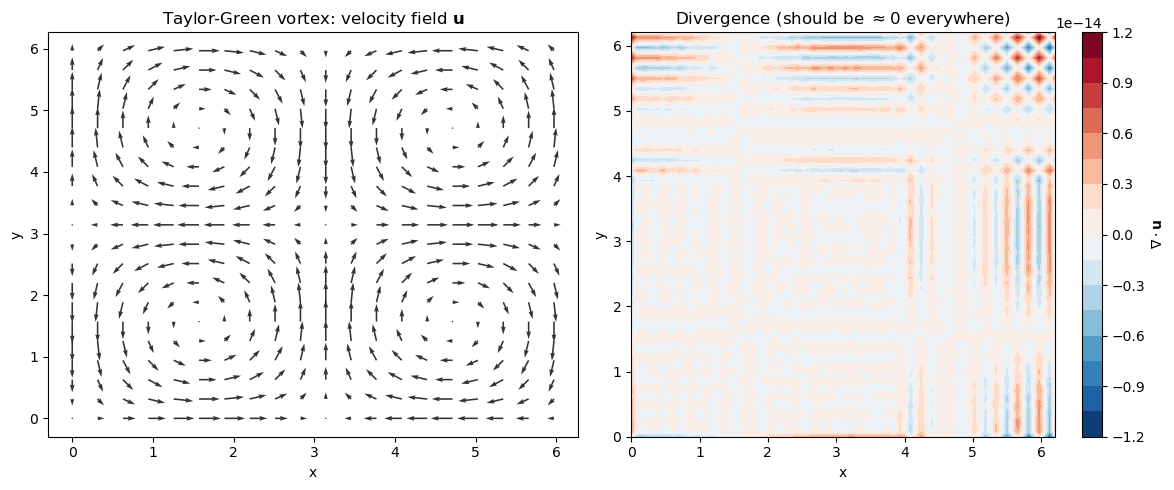

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Verify the incompressibility condition on a known flow field
# Taylor-Green vortex: u = sin(x)cos(y), v = -cos(x)sin(y)
# Exact divergence = cos(x)cos(y) - cos(x)cos(y) = 0 everywhere

N = 80
x = np.linspace(0, 2*np.pi, N, endpoint=False)
y = np.linspace(0, 2*np.pi, N, endpoint=False)
dx = x[1] - x[0]
dy = y[1] - y[0]
X, Y = np.meshgrid(x, y)

U = np.sin(X) * np.cos(Y)
V = -np.cos(X) * np.sin(Y)

# Compute divergence numerically using central differences
dU_dx = (np.roll(U, -1, axis=1) - np.roll(U, 1, axis=1)) / (2*dx)
dV_dy = (np.roll(V, -1, axis=0) - np.roll(V, 1, axis=0)) / (2*dy)
div = dU_dx + dV_dy

print(f"Taylor-Green vortex: max |div u| = {np.max(np.abs(div)):.2e}")
print(f"(Should be ~0 — this field is divergence-free)")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Velocity field
skip = 4
axes[0].quiver(X[::skip, ::skip], Y[::skip, ::skip],
               U[::skip, ::skip], V[::skip, ::skip], alpha=0.8)
axes[0].set_title('Taylor-Green vortex: velocity field $\\mathbf{u}$')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')

# Divergence
cf = axes[1].contourf(X, Y, div, levels=20, cmap='RdBu_r')
plt.colorbar(cf, ax=axes[1], label='$\\nabla \\cdot \\mathbf{u}$')
axes[1].set_title('Divergence (should be $\\approx 0$ everywhere)')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')

plt.tight_layout()
plt.show()

In [2]:
# Mass flux through a control volume — the bucket analogy in code
# Consider a 1D pipe section: u(x) varies linearly (u = 1 + 0.5x)
# Conservation requires: d(rho)/dt = -d(rho*u)/dx

x_cv = np.array([1.0, 2.0])  # control volume from x=1 to x=2
rho = 1.0  # constant density

u_left  = 1.0 + 0.5 * x_cv[0]   # velocity at left face
u_right = 1.0 + 0.5 * x_cv[1]   # velocity at right face

flux_in  = rho * u_left           # mass flux entering  (kg/m²/s)
flux_out = rho * u_right          # mass flux leaving
net_flux = flux_out - flux_in     # positive = net outflow

# Analytical: d(rho*u)/dx = rho * du/dx = rho * 0.5 = 0.5
exact_div = rho * 0.5

print(f"Flux in  (left face):  {flux_in:.3f} kg/m²/s")
print(f"Flux out (right face): {flux_out:.3f} kg/m²/s")
print(f"Net outflow:           {net_flux:.3f} kg/m²/s  (over dx=1m → divergence={net_flux:.3f})")
print(f"Analytical divergence: {exact_div:.3f}")
print("\nConclusion: this flow is compressible (div≠0) — density would decrease over time.")

Flux in  (left face):  1.500 kg/m²/s
Flux out (right face): 2.000 kg/m²/s
Net outflow:           0.500 kg/m²/s  (over dx=1m → divergence=0.500)
Analytical divergence: 0.500

Conclusion: this flow is compressible (div≠0) — density would decrease over time.


## Summary of the Three Conservation Laws

| Law | Quantity conserved | PDE |
|-----|--------------------|-----|
| Mass | $\rho$ | $\partial_t \rho + \nabla \cdot (\rho \mathbf{u}) = 0$ |
| Momentum | $\rho \mathbf{u}$ | $\partial_t(\rho\mathbf{u}) + \nabla \cdot (\rho \mathbf{u}\mathbf{u}) = -\nabla p + \mu\nabla^2\mathbf{u}$ |
| Energy | $\rho E$ | $\partial_t(\rho E) + \nabla \cdot[(\rho E+p)\mathbf{u}] = \nabla\cdot(k\nabla T)$ |

## Key Takeaways

- All CFD equations are conservation laws in disguise: *rate of change = flux in − flux out + sources*.
- The incompressibility constraint $\nabla \cdot \mathbf{u} = 0$ is the most important equation in
  incompressible CFD — it links velocity to pressure.
- The Divergence Theorem converts volume integrals to surface integrals — the basis of FVM.
- Every term in the N-S equations has a physical meaning you should be able to state in plain English.

---

**Next**: Lesson 1.4 — The Continuity Equation in depth: derivation, incompressible form, physical meaning.
